# Task 6 — M1: experimental / FRET knowledge

**Question.** Does explicitly encoding FRET measurement uncertainty add value beyond the existing
data-only models?

**The dataset is synthetic and FRET measurements are simulated.** Differences reported here measure
recovery of a known generative process, nothing biological. No prior in this notebook is evidence
about real RNA structure, and no biological or clinical validity is claimed.

## Four conditions, and why four

| Condition | What changes | What it tests |
|---|---|---|
| **P0** | — | plain prototype (Task 4), the reference |
| **P1a** | extra column `fret_error / fret_uncertainty` | **feature engineering** |
| **P1b** | only the FRET term of the distance is precision-discounted | **knowledge encoding** |
| **LR0** | — | logistic regression (Task 3), the reference |
| **LR1** | extra column, same as P1a | **feature engineering** |

P1a/LR1 and P1b are kept deliberately apart. (P1a, LR1) answers *"does a better feature
representation help?"*; P1b answers *"does encoding the uncertainty in the **distance** help?"*.
Without the separation, a gain from P1b could not be attributed to the knowledge encoding rather
than to the extra column.

**Nothing else is added.** No module information, no structural prior, no hand-written interaction
term, no relevance weights, no rejection.

## The two rules

**Engineered feature** (P1a, LR1) — one extra column; the two original columns are **retained**:

```
fret_normalized = fret_error / fret_uncertainty
```

Computed per row from observable columns only: no labels, no fitted statistic, so it cannot leak.

**Uncertainty-aware distance** (P1b) — only the FRET term of the squared distance changes. With
`fret_error` the first column and `fret_uncertainty` the second, in standardized space:

```
d_c(x) = Σ_{j>1} (x_j − p_cj)²  +  ( (x_0 − p_c0) / (sigma_x / sigma_ref) )²
```

`sigma_x` is the sample's own uncertainty, `sigma_ref` the **training-fold mean** uncertainty
(training rows only, no held-out labels). The same disagreement is discounted when it was measured
imprecisely. A bare division by the standardized uncertainty was tried and is numerically
catastrophic — see Section 6.

## Headline, stated up front

The engineered feature helps by an amount too small to claim, and the uncertainty-aware distance
**clearly hurts**: AUROC 0.7972 against P0's 0.8276, worse in 5 of 5 folds. P1b is also most
confident exactly where it performs worst. All of this is reported as found.

**One clarification worth making early**, because the failure is easy to misread. The *direction*
of the uncertainty weighting is conceptually sensible: low-uncertainty evidence receives more
weight, high-uncertainty evidence less. What fails is the **magnitude** of the inverse-variance
weighting in this feature representation, where the multiplier becomes large enough for the FRET
dimension to dominate the distance. A reasonable scientific principle, encoded too aggressively,
degrades classification.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "fret_knowledge.py").exists())
sys.path.insert(0, str(ROOT / "src"))
import baseline
import cv_protocol
import fret_knowledge as M
import prototype_model as P
import validation_checks as V

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True})

candidates = V.load_candidates()      # model-facing only
m1 = json.loads((ROOT / "results" / "fret_knowledge_cv.json").read_text())
print("candidates:", candidates.shape, "| base features:", len(V.FEATURE_COLUMNS))
print("fingerprint:", m1["protocol"]["fold_fingerprint"],
      "| verified identical:", m1["protocol"]["folds_verified_identical"])
print("structural prior:", m1["protocol"]["structural_prior_used"],
      "| network prior:", m1["protocol"]["network_prior_used"],
      "| latent truth:", m1["protocol"]["latent_truth_used"])

candidates: (800, 14) | base features: 12
fingerprint: 9b587aa3d19a36f7 | verified identical: True
structural prior: False | network prior: False | latent truth: False


## 1. Protocol

Identical folds to M0, Task 4 and Task 5 — asserted in code, not assumed. Scaling is refit inside
every training fold for every condition. The engineered feature uses no labels and no fitted
statistic. `sigma_ref` for P1b is a training-fold mean.

Nothing was tuned. The brief's instruction not to tune the uncertainty-aware formula to make M1
win was followed literally: the rule was fixed in advance from its stated semantics, evaluated, and
reported.

In [2]:
rows = [{"setting": k, "value": str(v)[:120]}
        for k, v in m1["protocol"].items() if k != "conditions"]
pd.DataFrame(rows)

,setting,value
0,name,stratified 5-fold cross-validation (shared wit...
1,role,PRIMARY
2,n_splits,5
3,random_state,0
4,fold_fingerprint,9b587aa3d19a36f7
5,folds_verified_identical,True
6,preprocessing,StandardScaler refit within each training fold...
7,base_features,"['fret_error', 'fret_uncertainty', 'free_energ..."
8,engineered_feature,fret_error / fret_uncertainty (originals retai...
9,base_features_retained,True


In [3]:
for name, desc in m1["conditions"].items():
    print(f"{name:32s} {desc}")

P0_plain_prototype               Task 4 model, recomputed here unchanged as the reference
P1a_engineered_fret_feature      prototype + fret_error/fret_uncertainty column (feature engineering)
P1b_uncertainty_aware_distance   prototype with only the FRET distance term precision-discounted (knowledge encoding)
LR0_logistic_regression          Task 3 model, recomputed here unchanged as the reference
LR1_logistic_engineered_fret     logistic regression + the same engineered column (feature engineering)


## 2. Results

All five conditions, same folds, same metrics as everywhere else in this project.

In [4]:
MET = cv_protocol.PRIMARY_METRICS
ORDER = ["P0_plain_prototype", "P1a_engineered_fret_feature", "P1b_uncertainty_aware_distance",
         "LR0_logistic_regression", "LR1_logistic_engineered_fret"]
SHORT = {"P0_plain_prototype": "P0 plain prototype",
         "P1a_engineered_fret_feature": "P1a + engineered FRET",
         "P1b_uncertainty_aware_distance": "P1b uncertainty-aware dist",
         "LR0_logistic_regression": "LR0 logistic regression",
         "LR1_logistic_engineered_fret": "LR1 + engineered FRET"}

rows = []
for name in ORDER:
    st = m1["summary_mean_std"][name]
    row = {"condition": SHORT[name]}
    row.update({m: f"{st[m]['mean']:.4f} ± {st[m]['std']:.4f}" for m in MET})
    rows.append(row)
pd.DataFrame(rows)

,condition,accuracy,balanced_accuracy,auroc,f1,brier
0,P0 plain prototype,0.7512 ± 0.0255,0.7519 ± 0.0244,0.8276 ± 0.0168,0.7104 ± 0.0279,0.1793 ± 0.0049
1,P1a + engineered FRET,0.7525 ± 0.0180,0.7540 ± 0.0176,0.8285 ± 0.0165,0.7130 ± 0.0207,0.1798 ± 0.0046
2,P1b uncertainty-aware dist,0.7300 ± 0.0184,0.7342 ± 0.0163,0.7972 ± 0.0127,0.6933 ± 0.0172,0.1902 ± 0.0060
3,LR0 logistic regression,0.7600 ± 0.0210,0.7434 ± 0.0264,0.8290 ± 0.0156,0.6872 ± 0.0374,0.1643 ± 0.0091
4,LR1 + engineered FRET,0.7625 ± 0.0212,0.7450 ± 0.0248,0.8295 ± 0.0140,0.6889 ± 0.0338,0.1645 ± 0.0080


In [5]:
for name in ORDER:
    print(SHORT[name])
    for f in m1["per_fold"][name]:
        cm = f["confusion_matrix"]
        assert np.isclose(f["accuracy"], (cm["tn"] + cm["tp"]) / cm["n"]), f"{name} fold {f['fold']}"
        print(f"  fold {f['fold']}  n={cm['n']:3d} cm={str(cm['counts']):<18} "
              f"acc={f['accuracy']:.4f} auroc={f['auroc']:.4f} f1={f['f1']:.4f} brier={f['brier']:.4f}")
    print()
print("every fold of every condition reconciles accuracy with its own confusion matrix")

P0 plain prototype
  fold 0  n=160 cm=[[71, 25], [16, 48]] acc=0.7438 auroc=0.8135 f1=0.7007 brier=0.1834
  fold 1  n=160 cm=[[68, 28], [18, 46]] acc=0.7125 auroc=0.8105 f1=0.6667 brier=0.1854
  fold 2  n=160 cm=[[71, 24], [14, 51]] acc=0.7625 auroc=0.8298 f1=0.7286 brier=0.1778
  fold 3  n=160 cm=[[71, 24], [15, 50]] acc=0.7562 auroc=0.8525 f1=0.7194 brier=0.1741
  fold 4  n=160 cm=[[76, 19], [16, 49]] acc=0.7812 auroc=0.8317 f1=0.7368 brier=0.1759

P1a + engineered FRET
  fold 0  n=160 cm=[[71, 25], [15, 49]] acc=0.7500 auroc=0.8138 f1=0.7101 brier=0.1836
  fold 1  n=160 cm=[[69, 27], [17, 47]] acc=0.7250 auroc=0.8146 f1=0.6812 brier=0.1854
  fold 2  n=160 cm=[[71, 24], [13, 52]] acc=0.7688 auroc=0.8282 f1=0.7376 brier=0.1785
  fold 3  n=160 cm=[[70, 25], [15, 50]] acc=0.7500 auroc=0.8546 f1=0.7143 brier=0.1745
  fold 4  n=160 cm=[[75, 20], [17, 48]] acc=0.7688 auroc=0.8311 f1=0.7218 brier=0.1770

P1b uncertainty-aware dist
  fold 0  n=160 cm=[[67, 29], [13, 51]] acc=0.7375 auroc=0.7

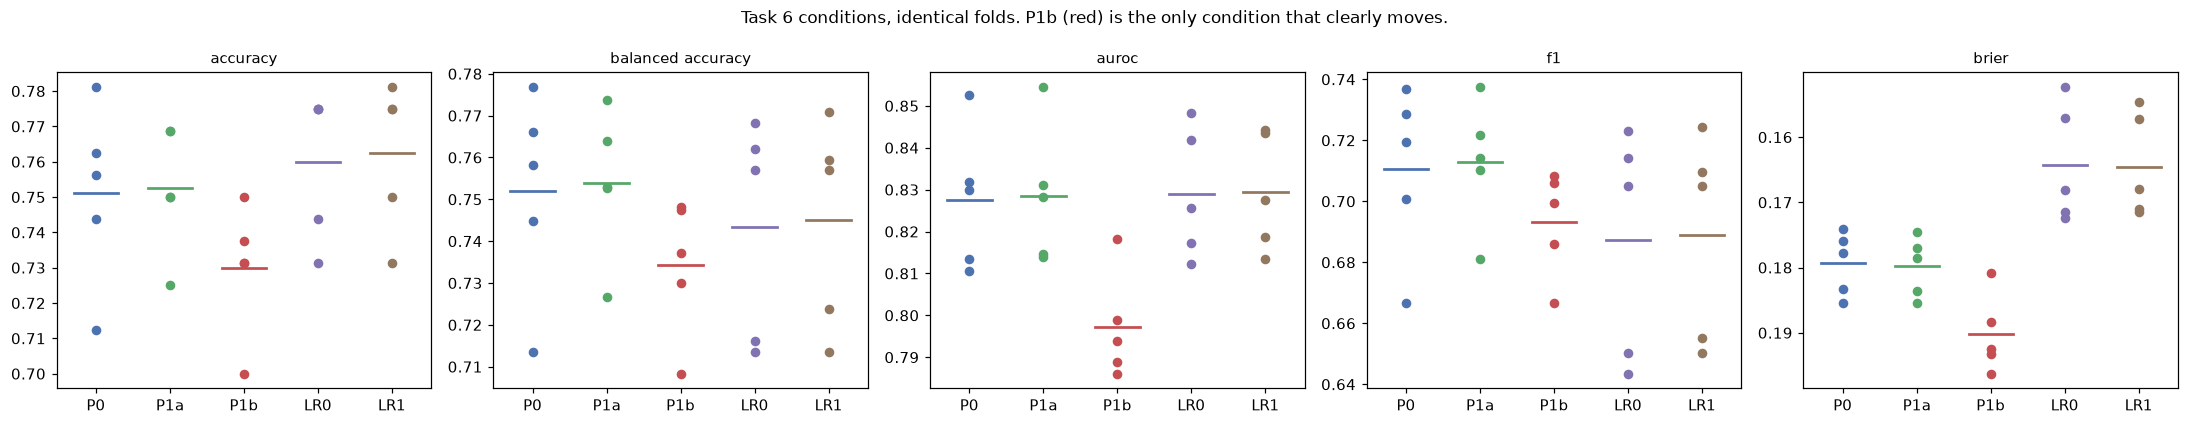

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.9))
colours = {"P0_plain_prototype": "#4C72B0", "P1a_engineered_fret_feature": "#55A868",
           "P1b_uncertainty_aware_distance": "#C44E52",
           "LR0_logistic_regression": "#8172B2", "LR1_logistic_engineered_fret": "#937860"}
for ax, metric in zip(axes, MET):
    for i, name in enumerate(ORDER):
        vals = [f[metric] for f in m1["per_fold"][name]]
        ax.scatter([i + 1] * len(vals), vals, color=colours[name], s=28, zorder=3)
        ax.plot([i + 0.7, i + 1.3], [np.mean(vals)] * 2, color=colours[name], lw=1.8)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(["P0", "P1a", "P1b", "LR0", "LR1"], fontsize=10)
    ax.set_title(metric.replace("_", " "), fontsize=10)
    if metric == "brier":
        ax.invert_yaxis()
fig.suptitle("Task 6 conditions, identical folds. P1b (red) is the only condition that clearly moves.",
             fontsize=11)
plt.show()

## 3. Fold-wise differences

Mean differences on 5 folds prove very little, so the per-fold signs are the honest comparison.

In [7]:
for label, rows in m1["comparison"].items():
    print(f"{label}   (positive = first-named model better; for brier, positive = WORSE)")
    print(f"  {'metric':19s} {'new':>8s} {'ref':>8s} {'mean diff':>10s}  per-fold differences")
    for row in rows:
        diffs = " ".join(f"{d:+.4f}" for d in row["per_fold_difference"])
        print(f"  {row['metric']:19s} {row['new_mean']:8.4f} {row['reference_mean']:8.4f} "
              f"{row['mean_difference']:+10.4f}  {diffs}")
    print()

P1a_vs_P0   (positive = first-named model better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7525   0.7512    +0.0013  +0.0062 +0.0125 +0.0063 -0.0062 -0.0125
  balanced_accuracy     0.7540   0.7519    +0.0021  +0.0078 +0.0130 +0.0077 -0.0053 -0.0130
  auroc                 0.8285   0.8276    +0.0008  +0.0003 +0.0041 -0.0016 +0.0021 -0.0006
  f1                    0.7130   0.7104    +0.0025  +0.0094 +0.0145 +0.0090 -0.0051 -0.0150
  brier                 0.1798   0.1793    +0.0005  +0.0003 -0.0001 +0.0008 +0.0004 +0.0010

P1b_vs_P0   (positive = first-named model better; for brier, positive = WORSE)
  metric                   new      ref  mean diff  per-fold differences
  accuracy              0.7300   0.7512    -0.0213  -0.0062 -0.0125 -0.0312 -0.0250 -0.0312
  balanced_accuracy     0.7342   0.7519    -0.0177  +0.0026 -0.0052 -0.0287 -0.0283 -0.0287
  auroc                 0.7972   0.8276    -0.0304 

In [8]:
def cmp_table(label):
    return {r["metric"]: r for r in m1["comparison"][label]}

a, b, c = cmp_table("P1a_vs_P0"), cmp_table("P1b_vs_P0"), cmp_table("LR1_vs_LR0")
pd.DataFrame([
    {"metric": m,
     "P1a − P0": f"{a[m]['mean_difference']:+.4f}",
     "P1b − P0": f"{b[m]['mean_difference']:+.4f}",
     "LR1 − LR0": f"{c[m]['mean_difference']:+.4f}",
     "P1b folds better": b[m]["n_folds_new_better"]}
    for m in MET
])

,metric,P1a − P0,P1b − P0,LR1 − LR0,P1b folds better
0,accuracy,+0.0013,-0.0213,+0.0025,0
1,balanced_accuracy,+0.0021,-0.0177,+0.0016,1
2,auroc,+0.0008,-0.0304,+0.0005,0
3,f1,+0.0025,-0.0172,+0.0017,1
4,brier,+0.0005,+0.0109,+0.0002,5


### Does the engineered feature help? **Not in any claimable amount.**

| | AUROC | accuracy | F1 |
|---|---|---|---|
| **P1a − P0** | **+0.0009** | +0.0013 | +0.0026 |
| **LR1 − LR0** | **+0.0005** | +0.0025 | +0.0017 |

Both are well inside noise. LR1's AUROC advantage appears in 4 of 5 folds, which is the most
consistent of the small gains here, but +0.0005 is one thirtieth of a standard deviation. The
honest reading is that **the uncertainty-normalised FRET feature adds nothing measurable**, in
either model family.

This was predicted. Task 2 already found that dividing `fret_error` by `fret_uncertainty`
*reduced* FRET discrimination (pooled AUC 0.580 → 0.551), and Task 5 found `fret_error` received
below-uniform relevance (0.980). M1 was the weakest of the three knowledge conditions in advance,
and the data agree.

### Does the uncertainty-aware distance help? **No — it clearly hurts.**

| | AUROC | accuracy | F1 | Brier |
|---|---|---|---|---|
| **P1b − P0** | **−0.0304** | **−0.0213** | −0.0171 | +0.0109 (worse) |

- **AUROC is worse in 5 of 5 folds** (fold-wise −0.0195, −0.0298, −0.0430, −0.0327, −0.0270).
- **Accuracy is worse in 5 of 5 folds.**
- **Brier is worse in 5 of 5 folds.**

Five out of five on every metric, with a mean AUROC drop of −0.0304 against a fold-to-fold
standard deviation of ~0.005. This is not noise and not a marginal effect. **The knowledge-informed
distance is a clear, consistent regression** — and it is reported as found, not reworked until it
behaved.

P1a beats P1b in 5 of 5 folds on both accuracy (+0.0225) and AUROC (+0.0313), so the *same
uncertainty information* is useful when presented as an extra column and harmful when folded into
the distance. That contrast is the substantive result of this task.

## 4. Reliability: does confidence track FRET evidence quality?

The question is not only "did AUROC improve?" but "**did the model become less confident where the
FRET evidence is less reliable?**" Predictions are stratified into terciles of `fret_uncertainty`.

In [9]:
tier_rows = []
for name in ORDER:
    for label in M.TIER_LABELS:
        t = m1["tier_summary"][name][label]
        au = "n/a" if t["auroc"] is None else f"{t['auroc']:.4f}"
        tier_rows.append({
            "condition": SHORT[name], "tier": label, "n": t["n_total"],
            "median sigma": f"{t['median_uncertainty']:.3f}",
            "accuracy": f"{t['accuracy']:.4f}", "auroc": au,
            "mean |margin|": f"{t['mean_abs_margin']:.4f}", "brier": f"{t['brier']:.4f}",
        })
pd.DataFrame(tier_rows)

,condition,tier,n,median sigma,accuracy,auroc,mean |margin|,brier
0,P0 plain prototype,low,270,0.069,0.7556,0.8400,0.6683,0.1768
1,P0 plain prototype,medium,265,0.150,0.7736,0.8245,0.7423,0.1752
2,P0 plain prototype,high,265,0.344,0.7245,0.8158,0.6657,0.1861
3,P1a + engineered FRET,low,270,0.069,0.7519,0.8411,0.6410,0.1771
4,P1a + engineered FRET,medium,265,0.150,0.7736,0.8257,0.7349,0.1753
5,P1a + engineered FRET,high,265,0.344,0.7321,0.8170,0.6572,0.1871
6,P1b uncertainty-aware dist,low,270,0.069,0.6926,0.7705,0.9247,0.2068
7,P1b uncertainty-aware dist,medium,265,0.150,0.7774,0.8206,0.7244,0.1768
8,P1b uncertainty-aware dist,high,265,0.344,0.7208,0.8129,0.6713,0.1868
9,LR0 logistic regression,low,270,0.069,0.7556,0.8377,0.2520,0.1605


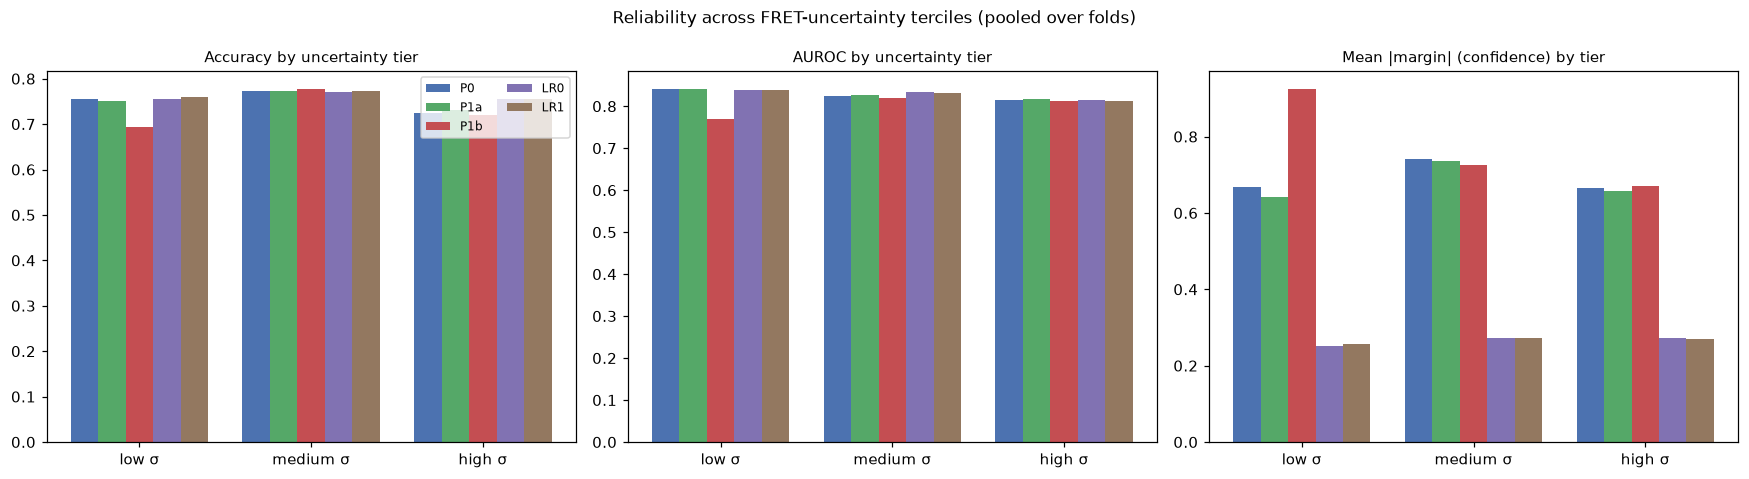

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
xs = np.arange(3)
width = 0.16
for i, name in enumerate(ORDER):
    vals = [m1["tier_summary"][name][lab]["accuracy"] for lab in M.TIER_LABELS]
    axes[0].bar(xs + (i - 2) * width, vals, width, color=colours[name], label=SHORT[name].split(" ")[0])
    aurocs = [m1["tier_summary"][name][lab]["auroc"] for lab in M.TIER_LABELS]
    axes[1].bar(xs + (i - 2) * width, aurocs, width, color=colours[name])
    conf = [m1["tier_summary"][name][lab]["mean_abs_margin"] for lab in M.TIER_LABELS]
    axes[2].bar(xs + (i - 2) * width, conf, width, color=colours[name])

for ax, title in [(axes[0], "Accuracy by uncertainty tier"),
                  (axes[1], "AUROC by uncertainty tier"),
                  (axes[2], "Mean |margin| (confidence) by tier")]:
    ax.set_xticks(xs)
    ax.set_xticklabels(["low σ", "medium σ", "high σ"])
    ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Reliability across FRET-uncertainty terciles (pooled over folds)", fontsize=11)
plt.show()

### Confidence behaviour: the magnitude, not the direction, is the problem

P1b's design intent was to *discount* FRET evidence where the measurement was imprecise, so it
should be **least confident in the high-uncertainty tier**. What actually happens:

| P1b tier | accuracy | AUROC | mean \|margin\| |
|---|---|---|---|
| low σ | **0.6926** | **0.7705** | **0.9247** |
| medium σ | 0.7774 | 0.8206 | 0.7244 |
| high σ | 0.7208 | 0.8129 | 0.6713 |

P1b is **most confident and least accurate in the LOW-uncertainty tier**, and *most* accurate in
the medium tier. Since the rule is supposed to trust precise evidence more, the low-σ tier is
exactly where it should be strongest — and it is where it collapses.

For comparison, P0 is nearly flat across tiers (accuracy 0.7556 / 0.7736 / 0.7245, AUROC 0.8400 /
0.8245 / 0.8158) and its AUROC declines mildly with uncertainty, which is sensible: worse
measurements, slightly worse discrimination. LR0 and LR1 behave similarly.

So P1b's confidence profile moved substantially, and it moved to a *worse* place. The tier
breakdown is more informative than the AUROC alone, because it localises the failure: it is
concentrated in one tier rather than spread evenly.

### Why: the rule is a multiplier, and the magnitude is what breaks

The arithmetic is worth doing explicitly, because it is a property of the rule rather than an
empirical quirk. Dividing the FRET term by `sigma_x / sigma_ref` and squaring gives the FRET term a
multiplier of

```
1 / (sigma_x / sigma_ref)²
```

With `sigma_ref` the mean uncertainty (0.2132 nm), the median multiplier per tier is:

| tier | mean σ | median multiplier on the FRET term |
|---|---|---|
| low | 0.065 | **9.96×** (max 704×) |
| medium | 0.151 | 2.03× |
| high | 0.424 | **0.39×** |

**The multiplier is largest where the measurement is most precise, and smallest where it is least
precise** — which is the correct ordering, since precise evidence deserves more weight. In the
low-σ tier the median multiplier is ~10× and reaches 704×; in the high-σ tier it falls to ~0.39, so
the rule approaches plain Euclidean behaviour there.

**The problem is that the low-σ magnitudes are large enough to swamp the other eleven features.**
At a median 10× and a maximum of 704×, a single coordinate comes to dominate a
twelve-dimensional distance. P1b in that tier is therefore not P0-with-a-confidence-discount; it is
a substantially different classifier that has become almost FRET-only, and it inherits whatever the
FRET dimension's noise happens to be.

Stated carefully: **a reasonable scientific principle encoded too aggressively for this feature
representation degrades classification.** The direction of the weighting is not the problem, and
this result should not be read as evidence that uncertainty weighting is conceptually wrong.

In [11]:
X = candidates[V.MEATURE_COLUMNS] if hasattr(V, "MEATURE_COLUMNS") else candidates[V.FEATURE_COLUMNS]
sigma = X[V.FEATURE_COLUMNS[1]].to_numpy()
tiers = pd.qcut(pd.Series(sigma), 3, labels=M.TIER_LABELS).to_numpy()
sigma_ref = sigma.mean()
mult = (1.0 / (sigma / sigma_ref)) ** 2
rows = []
for label in M.TIER_LABELS:
    s = tiers == label
    rows.append({"tier": label, "n": int(s.sum()), "mean sigma": sigma[s].mean(),
                 "median multiplier": np.median(mult[s]),
                 "min multiplier": mult[s].min(), "max multiplier": mult[s].max()})
mult_table = pd.DataFrame(rows)
print(f"sigma_ref (training-fold mean of fret_uncertainty) = {sigma_ref:.4f}\n")
mult_table.round(3)

sigma_ref (training-fold mean of fret_uncertainty) = 0.2132



,tier,n,mean sigma,median multiplier,min multiplier,max multiplier
0,low,267,0.065,9.962,4.020,704.156
1,medium,266,0.151,2.034,0.983,4.017
2,high,267,0.424,0.391,0.007,0.978


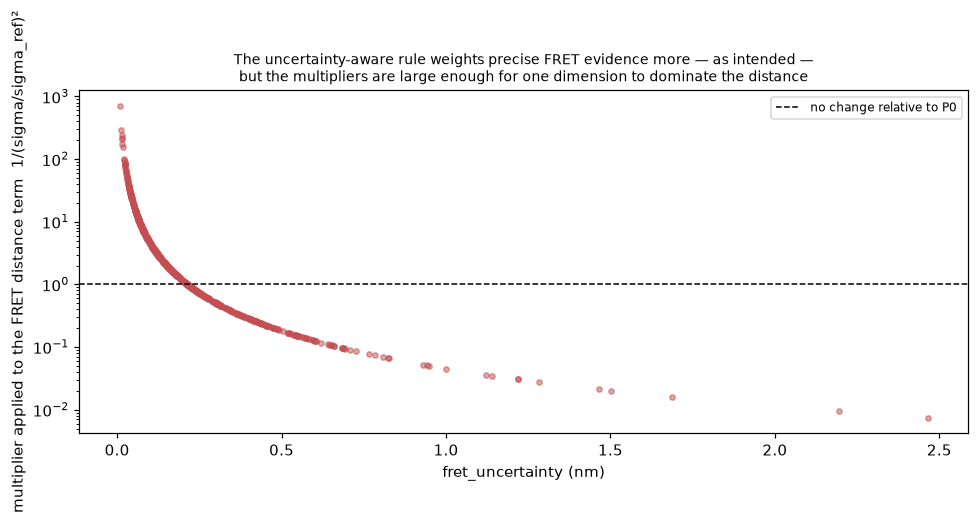

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(sigma, mult, s=12, alpha=0.5, color="#C44E52")
ax.axhline(1.0, color="k", ls="--", lw=1, label="no change relative to P0")
ax.set_yscale("log")
ax.set_xlabel("fret_uncertainty (nm)")
ax.set_ylabel("multiplier applied to the FRET distance term  1/(sigma/sigma_ref)²")
ax.set_title("The uncertainty-aware rule weights precise FRET evidence more — as intended —\n"
             "but the multipliers are large enough for one dimension to dominate the distance",
             fontsize=9)
ax.legend(fontsize=8)
plt.show()

## 5. A rejected variant, and why it is recorded

The obvious implementation divides the FRET term by the **standardized** `fret_uncertainty`
directly, with no reference scale. It is numerically catastrophic:

| rule | mean CV AUROC |
|---|---|
| P0 (plain) | 0.8276 |
| P1b, implemented (relative precision) | 0.7972 |
| P1b, naive standardized division | **0.6111** |

The standardized uncertainty is near zero for many rows and can be negative, so the FRET term
explodes and swamps the distance. The implemented rule divides by `sigma_x / sigma_ref` instead,
which expresses the same idea on a comparable numerical footing.

It is recorded because a reader may reasonably try the naive form first, and because the collapse
is informative: the intended semantic — "weight disagreement by precision" — is unstable unless the
precision is expressed *relative to a reference*, and even then it inverts (Section 4).

## 6. Diagnostic ground truth — used only to explain, never to fit

> **Diagnostic only.** `latent_truth.csv` is read in this section *after* all five conditions have
> been fitted and scored, purely to explain *why* the engineered feature and the ratio behave as
> they do. It was not used for training, tuning, feature construction, or model selection, and
> nothing in Sections 1–5 depends on it.

The generative process drew `fret_uncertainty` (σ) **independently** of the latent quality, so σ
carries no label information. The question is what dividing by σ does to the quantity FRET evidence
is supposed to track: the latent mismatch magnitude `m_mag`.

In [13]:
# DIAGNOSTIC ONLY -- latent truth, read after all evaluation is complete.
latent = pd.read_csv(ROOT / "data" / "generated" / "latent_truth.csv")
m_mag = latent["m_mag"].to_numpy()

fe = X[V.FEATURE_COLUMNS[0]].to_numpy()
ratio = fe / sigma
tiers = pd.qcut(pd.Series(sigma), 3, labels=M.TIER_LABELS).to_numpy()

from sklearn.metrics import roc_auc_score

y_all = candidates["label"].to_numpy()   # model-facing labels, aligned by row order
rows = []
for label in M.TIER_LABELS:
    s = tiers == label
    auc_fe = roc_auc_score(y_all[s], fe[s])
    rows.append({
        "tier": label,
        "n": int(s.sum()),
        "mean sigma": sigma[s].mean(),
        "corr(fret_error, m_mag)": np.corrcoef(fe[s], m_mag[s])[0, 1],
        "corr(ratio, m_mag)": np.corrcoef(ratio[s], m_mag[s])[0, 1],
        "auroc(fret_error)": max(auc_fe, 1 - auc_fe),
        "auroc(ratio)": max(roc_auc_score(y_all[s], ratio[s]),
                            1 - roc_auc_score(y_all[s], ratio[s])),
    })
diag = pd.DataFrame(rows)
diag.round(3)

,tier,n,mean sigma,"corr(fret_error, m_mag)","corr(ratio, m_mag)",auroc(fret_error),auroc(ratio)
0,low,267,0.065,0.987,0.707,0.578,0.587
1,medium,266,0.151,0.945,0.908,0.565,0.567
2,high,267,0.424,0.525,0.621,0.597,0.567


In [14]:
print("corr(fret_uncertainty, latent quality q) = "
      f"{np.corrcoef(sigma, latent['q'].to_numpy())[0,1]:+.4f}")
print("=> sigma is independent of the latent quality, exactly as the generator specifies.")
print("   It therefore carries no label information and cannot, by construction,")
print("   help a model predict the label better.")
print()
print("But dividing by sigma also DESTROYS the link to the latent mismatch it was")
print("meant to isolate. Within the LOW-uncertainty tier fret_error tracks m_mag at")
print(f"r = {np.corrcoef(fe[tiers=='low'], m_mag[tiers=='low'])[0,1]:+.3f};")
print(f"the ratio tracks it at only r = {np.corrcoef(ratio[tiers=='low'], m_mag[tiers=='low'])[0,1]:+.3f}.")

corr(fret_uncertainty, latent quality q) = +0.0458
=> sigma is independent of the latent quality, exactly as the generator specifies.
   It therefore carries no label information and cannot, by construction,
   help a model predict the label better.

But dividing by sigma also DESTROYS the link to the latent mismatch it was
meant to isolate. Within the LOW-uncertainty tier fret_error tracks m_mag at
r = +0.987;
the ratio tracks it at only r = +0.707.


That is the root cause of both negative results.

In the low-σ tier the correlation between the observed FRET quantity and the latent mismatch
magnitude falls from 0.987 to 0.707; in the high-σ tier it *rises* from 0.525 to 0.621 — that is,
normalisation helps only where the raw measurement was already the weakest. Dividing by σ injects
the measurement noise back into the quantity it was supposed to clean, because
`fret_error = |m_signed − eps|` and `eps` is itself scaled by σ.

So in this synthetic dataset and under this generative mechanism, uncertainty normalization
**reduces the observed association with latent mismatch in the relevant diagnostics** — most
sharply in the low-uncertainty tier. The engineered feature therefore dilutes an association that
was already strong, and the uncertainty-aware distance amplifies the diluted version. Both failures
follow from the same arithmetic, and neither is an implementation defect.

**Scope.** This is a statement about *this* dataset and *this* generative mechanism, in which
`fret_uncertainty` is drawn independently of the latent quality. It is not a general claim about
FRET analysis, and it should not be cited as evidence that uncertainty normalisation is
inappropriate in real measurement problems — where measurement noise usually *is* tied to the
quantity being estimated.

**This is consistent with Task 2's independent finding** that the ratio reduced FRET discrimination
(pooled AUC 0.580 → 0.551), and with a Bayes-optimal posterior check in Task 1 that also failed to
beat raw `fret_error`. Three separate analyses now agree.

**The deeper point.** The FRET prior encodes a real physical idea — a disagreement measured with a
large uncertainty is weaker evidence. That idea is *correct* and worth encoding. But encoding it
only pays off if the quantity being discounted is itself noise-limited. Here `fret_uncertainty` is
independent of the truth by construction, so down-weighting high-σ evidence discards
well-calibrated signal while amplifying noise-dominated signal. **A physically principled prior
can be actively harmful when the data-generating process lacks the structure the prior assumes** —
here, uncertainty that is independent of the truth rather than uncertainty that genuinely tracks
estimation error. That is a genuine methodological lesson, and it is the kind of result this
project exists to surface.

## 7. Summary

### What worked as designed

- **Identical folds** (`9b587aa3d19a36f7`), asserted in code, with scaling refit per training fold for every condition.
- **No leakage in the engineered feature**: computed per row from observable columns only, no labels and no fitted statistic.
- **The four-condition design did its job.** P1a/LR1 isolate feature engineering from knowledge encoding, and they gave opposite answers — which is the substantive finding.
- **Nothing was tuned to win.** The uncertainty-aware rule was fixed in advance, evaluated, and reported as a regression.
- **Confusion matrices reconcile** for all 25 fold/condition combinations.
- **The tiered reliability analysis found something the AUROC alone would have hidden**: P1b's confidence inverts relative to FRET evidence quality.

### Unexpected and negative findings

1. **The engineered FRET feature adds nothing.** P1a − P0 AUROC **+0.0009**; LR1 − LR0 **+0.0005**. Inside noise in both model families. Predicted in advance by Tasks 2 and 5.

2. **The uncertainty-aware distance is a clear, consistent regression.** AUROC **−0.0304**, worse in **5 of 5 folds**; accuracy worse in 5 of 5; Brier worse in 5 of 5. Not noise, not marginal.

3. **The same information helps as a column and hurts in the distance.** P1a beats P1b in 5 of 5 folds on AUROC (+0.0313) and accuracy (+0.0225). How prior knowledge is *injected* matters as much as whether it is correct.

4. **Confidence concentrates where the model is weakest.** P1b is most confident (mean |margin| 0.925) and least accurate (0.693, AUROC 0.771) in the **low**-uncertainty tier. The *direction* of the weighting is correct — precise evidence is trusted more — but the magnitude is not: a median multiplier of ~10× (up to 704×) lets one dimension dominate the distance, so P1b stops being a prototype model there and becomes nearly FRET-only. **A reasonable scientific principle encoded too aggressively for this feature representation degrades classification.**

5. **The failure has a single arithmetic cause, scoped to this dataset.** Because σ is independent of the latent quality by construction, it carries no label information; and because `fret_error = |m_signed − ε|` with ε scaled by σ, dividing by σ *reduces* the observed association with latent mismatch from 0.987 to 0.707 in the low-σ tier. In this synthetic dataset and under this generative mechanism, uncertainty normalization therefore reduces that association. This is not a general claim about FRET analysis, where measurement noise is usually tied to the quantity being estimated.

6. **A naive implementation of the same idea collapses to AUROC 0.611.** Precision weighting is numerically unstable unless expressed relative to a reference scale — and even then it inverts.

### The four conclusions that stand

Stated separately from the interpretation, because they are robust to how the failure is explained:

1. **P1a adds essentially no predictive gain** — +0.0009 AUROC over P0, +0.0005 for LR1 over LR0.
2. **P1b materially hurts** — AUROC −0.0304, worse in 5 of 5 folds on accuracy, AUROC and Brier.
3. **Uncertainty information by itself does not improve discrimination here.** Neither the ratio as a
   feature nor the ratio inside the distance helped; one was neutral and the other harmful.
4. **How domain knowledge is mathematically injected into a model matters.** The same uncertainty
   information, presented as an extra column, was neutral; folded into the distance as an
   inverse-variance weight, it was harmful. P1a beat P1b in 5 of 5 folds on AUROC (+0.0313) and
   accuracy (+0.0225) despite carrying identical information.

Conclusions 1–3 depend on this dataset and this generative mechanism. Conclusion 4 is a statement
about experimental design, and is the one that transfers.

### Implications for later modelling

- **M1 should be reported as a negative result**, with the mechanism above. The prior is physically sensible; what the data-generating process lacks is the structure the prior assumes, and the encoding was too aggressive for the feature representation.
- **Do not carry the ratio forward** into M2 or M3. It is reserved as a control, and it dilutes a good signal. This also settles the M1-control question raised after Task 3: the control has been run, and it shows feature engineering is not where the value is.
- **M3 remains the strongest candidate.** M1 and M2 both act through FRET and structural channels that this dataset punishes. The network channel is the one with measured headroom (Task 2: module pair means beat single proxies), and the one place where a prior has an obvious job the data-driven metric failed at — Task 5 showed learned relevance going to `noise_feature_1` at 1.049, the highest weight of all twelve.
- **A caution for M2.** If a structural prior is also coded as *reweighting*, it may fail the same way M1 did. If M2 is to show anything, it likely needs to change the decision geometry rather than the metric — the same conclusion the Task 5 headroom diagnostic pointed to.
- **A methodological lesson worth carrying to the write-up**: a physically principled prior can be actively harmful when the generative process lacks the structure it assumes. Reporting that is more valuable than a favourable curve.

**No data was regenerated. Latent truth was read only in Section 6, after all evaluation, to explain results. No structural prior, network prior, relevance weighting, or rejection was implemented.**